# Identificación temprana de lenguaje asociado a riesgo suicida para fines de prevención

El suicidio constituye un problema de salud pública de alta complejidad, influido por factores psicológicos, sociales, culturales y económicos. Debido a su naturaleza multifactorial, la prevención requiere estrategias integrales que permitan identificar señales de alerta de manera oportuna y facilitar la canalización hacia apoyo profesional.

En este proyecto se propone un enfoque de ciencia de datos para analizar dos dimensiones complementarias del problema. Por un lado, se realiza un análisis exploratorio de datos epidemiológicos con el fin de observar patrones generales asociados al suicidio, particularmente diferencias por sexo y generación. Por otro lado, se desarrolla un modelo de procesamiento de lenguaje natural capaz de identificar texto con señales asociadas a riesgo suicida.

Es importante señalar que este sistema no tiene como objetivo realizar diagnósticos clínicos ni sustituir la valoración de profesionales de salud mental. Su propósito es funcionar como una herramienta de apoyo para la detección temprana, priorización de casos y fortalecimiento de estrategias de prevención.

## Pregunta general de investigación

¿Es posible identificar de manera automática patrones lingüísticos asociados a riesgo suicida en publicaciones de texto, de forma que puedan emplearse como apoyo en estrategias de prevención y detección temprana?

## Objetivo general

Desarrollar un modelo de aprendizaje automático para identificar texto con señales asociadas a riesgo suicida, utilizando técnicas de procesamiento de lenguaje natural, y complementarlo con un análisis exploratorio de datos epidemiológicos que aporte contexto al problema.

## Objetivos específicos

1. Analizar diferencias descriptivas en variables relacionadas con suicidio a partir de datos históricos.
2. Construir un modelo base de clasificación de texto utilizando técnicas de preprocesamiento y vectorización.
3. Evaluar el desempeño del modelo con métricas adecuadas para problemas de clasificación.
4. Identificar limitaciones metodológicas y éticas del uso de modelos automáticos en contextos sensibles.
5. Proponer mejoras para hacer el sistema más robusto, interpretable y relevante.

## Estructura del proyecto

El proyecto se organiza en dos bloques principales:

1. **Análisis exploratorio con datos históricos (`master.csv`)**  
   Se utiliza para contextualizar el problema mediante patrones descriptivos por sexo y generación.

2. **Modelo de clasificación de texto (`Suicide_Detection.csv`)**  
   Constituye el núcleo del proyecto y busca identificar lenguaje asociado a riesgo suicida en publicaciones de texto.

Se elimina del planteamiento principal cualquier bloque basado en datos ficticios, ya que no aporta evidencia empírica sólida para sustentar el problema.

## Análisis exploratorio: diferencias por sexo en registros históricos de suicidio

Como parte del contexto del problema, se analiza si existen diferencias observables entre hombres y mujeres en los registros históricos disponibles. Este análisis no busca explicar causalmente el fenómeno, sino identificar patrones descriptivos que ayuden a contextualizar la relevancia del problema.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga del conjunto de datos histórico

In [4]:
tasa_s = pd.read_csv("sample_data/master.csv")
tasa_s.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [5]:
print("Dimensiones del dataset:", tasa_s.shape)
print("\nTipos de datos:")
print(tasa_s.dtypes)

Dimensiones del dataset: (27820, 12)

Tipos de datos:
country                   str
year                    int64
sex                       str
age                       str
suicides_no             int64
population              int64
suicides/100k pop     float64
country-year              str
HDI for year          float64
 gdp_for_year ($)         str
gdp_per_capita ($)      int64
generation                str
dtype: object


## 2. Revisión rápida de valores faltantes

In [6]:
datos_faltantes = tasa_s.isnull().sum().sort_values(ascending=False)
datos_faltantes[datos_faltantes > 0]

HDI for year    19456
dtype: int64

La variable `HDI for year` contiene valores faltantes, pero no forma parte del objetivo específico de este análisis. Por ello, se trabajará únicamente con las variables necesarias para explorar diferencias descriptivas por sexo y generación.

## 3. Selección y transformación de variables

In [7]:
tasa = tasa_s.loc[:, ["sex", "suicides_no", "population", "generation"]].copy()
tasa["proporcion"] = tasa["suicides_no"] / tasa["population"]
tasa.head()

,sex,suicides_no,population,generation,proporcion
0,male,21,312900,Generation X,0.000067
1,male,16,308000,Silent,0.000052
2,female,14,289700,Generation X,0.000048
3,male,1,21800,G.I. Generation,0.000046
4,male,9,274300,Boomers,0.000033


In [8]:
tasa.describe(include="all")

,sex,suicides_no,population,generation,proporcion
count,27820,27820.000000,2.782000e+04,27820,27820.000000
unique,2,NaN,NaN,6,NaN
top,male,NaN,NaN,Generation X,NaN
freq,13910,NaN,NaN,6408,NaN
mean,NaN,242.574407,1.844794e+06,NaN,0.000128
std,NaN,902.047917,3.911779e+06,NaN,0.000190
min,NaN,0.000000,2.780000e+02,NaN,0.000000
25%,NaN,3.000000,9.749850e+04,NaN,0.000009
50%,NaN,25.000000,4.301500e+05,NaN,0.000060
75%,NaN,131.000000,1.486143e+06,NaN,0.000166


## 4. Visualización descriptiva por sexo y generación

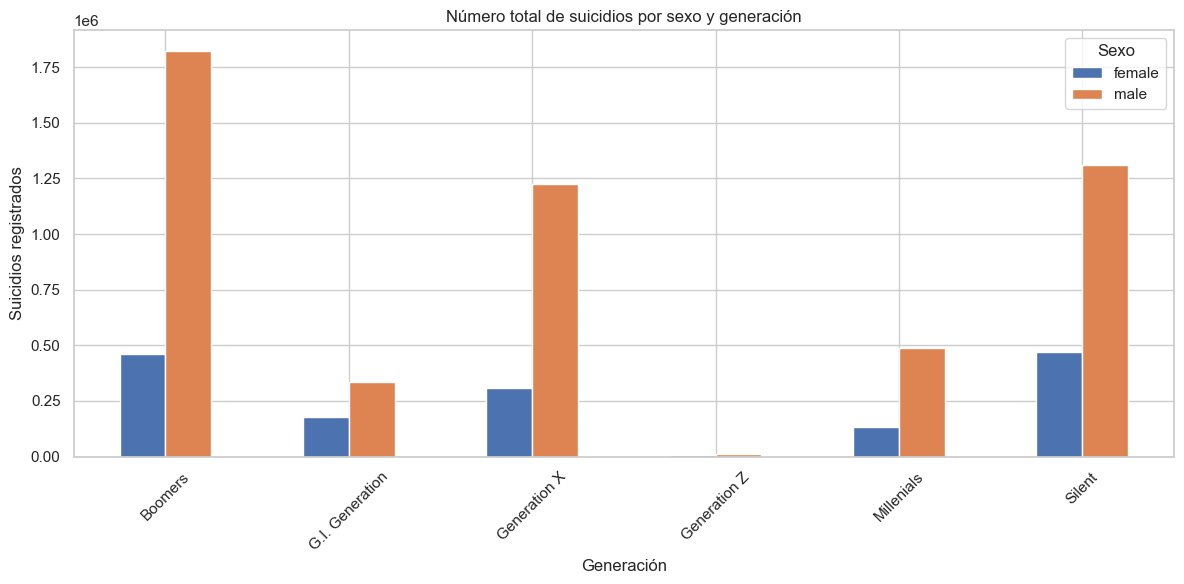

In [9]:
grouped_data = tasa.groupby(["sex", "generation"])["suicides_no"].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
grouped_data.T.plot(kind="bar", ax=ax)
ax.set_title("Número total de suicidios por sexo y generación")
ax.set_xlabel("Generación")
ax.set_ylabel("Suicidios registrados")
ax.legend(title="Sexo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A nivel descriptivo se observan diferencias importantes entre hombres y mujeres en distintas generaciones. No obstante, una diferencia visual no es suficiente para establecer una conclusión estadística, por lo que se realiza una prueba de hipótesis.

## 5. Prueba de hipótesis

Se comparan los registros de `suicides_no` entre hombres y mujeres.

**Hipótesis planteadas**

- **H0:** la distribución del número de suicidios en hombres es menor o igual que en mujeres.
- **H1:** la distribución del número de suicidios en hombres es mayor que en mujeres.

Antes de seleccionar la prueba estadística, se revisa el supuesto de normalidad.

In [10]:
mujeres = tasa[tasa["sex"] == "female"]["suicides_no"]
hombres = tasa[tasa["sex"] == "male"]["suicides_no"]

_, pvalue_hombres = stats.shapiro(hombres.sample(min(len(hombres), 5000), random_state=42))
_, pvalue_mujeres = stats.shapiro(mujeres.sample(min(len(mujeres), 5000), random_state=42))
_, p_equal_var = stats.levene(hombres, mujeres)

alpha = 0.01

print("Prueba de normalidad (Shapiro-Wilk)")
print(f"p-valor hombres: {pvalue_hombres:.6f}")
print(f"p-valor mujeres: {pvalue_mujeres:.6f}")

print("\nPrueba de igualdad de varianzas (Levene)")
print(f"p-valor: {p_equal_var:.6f}")

Prueba de normalidad (Shapiro-Wilk)
p-valor hombres: 0.000000
p-valor mujeres: 0.000000

Prueba de igualdad de varianzas (Levene)
p-valor: 0.000000


Si los datos no cumplen normalidad o presentan varianzas distintas, resulta más apropiado utilizar una prueba no paramétrica. Por ello se aplica la prueba **Mann-Whitney U**.

In [11]:
statistic, p_value = mannwhitneyu(hombres, mujeres, alternative="greater")

print("Estadístico U:", statistic)
print("Valor p:", p_value)

Estadístico U: 119868925.5
Valor p: 1.489876398039126e-262


## 6. Interpretación del análisis exploratorio

Si el valor p es menor que el nivel de significancia establecido, se rechaza la hipótesis nula y se concluye que existen diferencias estadísticamente significativas en la distribución del número de suicidios entre hombres y mujeres en los registros analizados.

Este resultado debe interpretarse únicamente como un hallazgo descriptivo dentro del conjunto de datos histórico. No implica por sí mismo causalidad ni permite afirmar riesgo individual.

# Clasificación de texto para identificación temprana de lenguaje de riesgo

El uso del auge de las redes sociales para prevenir el suicidio es un enfoque prometedor, ya que estas plataformas pueden proporcionar una gran cantidad de información y señales potenciales sobre el bienestar emocional de los usuarios.

La segunda parte del proyecto constituye el componente central del trabajo. Aquí se utiliza un conjunto de publicaciones de texto para entrenar un modelo de clasificación binaria que diferencie entre contenido asociado a riesgo suicida y contenido no asociado a ese riesgo. Es una colección de publicaciones de los subreddits "SuicideWatch" y "depresión" de la plataforma Reddit. Las publicaciones se recopilan mediante la API de Pushshift. Se recopilaron todas las publicaciones que se realizaron en "SuicideWatch" desde el 16 de diciembre de 2008 hasta el 2 de enero de 2021, mientras que las publicaciones de "depresión" se recopilaron desde el 1 de enero de 2009 hasta el 2 de enero de 2021. Todas las publicaciones recopiladas de SuicideWatch son etiquetado como suicidio, mientras que las publicaciones recopiladas del subreddit de depresión están etiquetadas como depresión. Las publicaciones de no suicidio se recopilan de adolescentes.

Esta formulación sigue siendo una simplificación del problema real. El objetivo no es diagnosticar, sino detectar señales lingüísticas que puedan motivar atención o revisión.


Disponible en: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch

## 7. Carga del conjunto de datos de texto

In [12]:
data_s = pd.read_csv("sample_data/Suicide_Detection.csv")
data_s.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [13]:
data_s.columns = ["id", "text", "class"]
data_s = data_s.drop(columns=["id"])
data_s.head()

,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [14]:
print(data_s["class"].value_counts(dropna=False))

class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


## 8. Limpieza inicial del dataset textual

In [15]:
data_s = data_s.dropna(subset=["text", "class"]).copy()
data_s["text"] = data_s["text"].astype(str)
data_s["class"] = data_s["class"].astype(str).str.strip().str.lower()

data_s = data_s[data_s["class"].isin(["suicide", "non-suicide"])].copy()
data_s = data_s.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Dimensiones después de limpieza:", data_s.shape)
data_s["class"].value_counts()

Dimensiones después de limpieza: (232074, 2)


class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

## 9. Muestreo de trabajo

Para reducir tiempo de cómputo, se seleccionara una muestra

In [16]:
sample_size = min(80000, len(data_s))
data_text = data_s.sample(n=sample_size, random_state=42).reset_index(drop=True)

print("Tamaño de muestra utilizado:", data_text.shape)
data_text.head()

Tamaño de muestra utilizado: (80000, 2)


,text,class
0,I Don't know?7? Months self harm free and the ...,suicide
1,I HAVE TO START BECOMING RICH I HAVE TO START ...,non-suicide
2,"A poem (haiku) for u/Me-Game-Dev hi, hello hel...",non-suicide
3,I've honestly got no idea what to do anymore.I...,suicide
4,Do you ever just cry? Like you just think abou...,non-suicide


## 10. Preprocesamiento de texto

In [17]:
nltk.download('punkt_tab')
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    tokens = [token for token in tokens if token not in stop_words]
    return " ".join(tokens)

data_text["clean_text"] = data_text["text"].apply(preprocess_text)
data_text[["text", "clean_text", "class"]].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ulises\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text,clean_text,class
0,I Don't know?7? Months self harm free and the ...,dont month self harm free urge get stronger st...,suicide
1,I HAVE TO START BECOMING RICH I HAVE TO START ...,start becoming rich start company become affor...,non-suicide
2,"A poem (haiku) for u/Me-Game-Dev hi, hello hel...",poem haiku umegamedev hi hello hello stop fuck...,non-suicide
3,I've honestly got no idea what to do anymore.I...,ive honestly got idea anymoreit feel everyone ...,suicide
4,Do you ever just cry? Like you just think abou...,ever cry like think unfair life cry cant cry e...,non-suicide


## 11. División en entrenamiento y prueba

In [18]:
X = data_text["clean_text"]
y = data_text["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (64000,)
Tamaño X_test: (16000,)


## 12. Modelos base a comparar

Se entrenan dos modelos base:

1. **Regresión logística con TF-IDF**
2. **SVM lineal con TF-IDF**

Estos modelos funcionan como línea base del proyecto antes de considerar modelos más avanzados.

In [19]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2))),
    ("clf", LinearSVC())
])

logreg_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)

pred_logreg = logreg_pipeline.predict(X_test)
pred_svm = svm_pipeline.predict(X_test)

In [20]:
def metricas(y_true, y_pred, nombre_modelo):
    return pd.DataFrame([{
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="suicide"),
        "recall": recall_score(y_true, y_pred, pos_label="suicide"),
        "f1": f1_score(y_true, y_pred, pos_label="suicide")
    }])

resultados = pd.concat([
    metricas(y_test, pred_logreg, "Regresión logística"),
    metricas(y_test, pred_svm, "SVM lineal")
], ignore_index=True)

resultados

,modelo,accuracy,precision,recall,f1
0,Regresión logística,0.9330,0.942967,0.92175,0.932238
1,SVM lineal,0.9315,0.938962,0.92300,0.930913


## 13. Reporte de clasificación

In [21]:
print("=== Regresión logística ===")
print(classification_report(y_test, pred_logreg))

print("\n=== SVM lineal ===")
print(classification_report(y_test, pred_svm))

=== Regresión logística ===
              precision    recall  f1-score   support

 non-suicide       0.92      0.94      0.93      8000
     suicide       0.94      0.92      0.93      8000

    accuracy                           0.93     16000
   macro avg       0.93      0.93      0.93     16000
weighted avg       0.93      0.93      0.93     16000


=== SVM lineal ===
              precision    recall  f1-score   support

 non-suicide       0.92      0.94      0.93      8000
     suicide       0.94      0.92      0.93      8000

    accuracy                           0.93     16000
   macro avg       0.93      0.93      0.93     16000
weighted avg       0.93      0.93      0.93     16000



## 14. Matrices de confusión

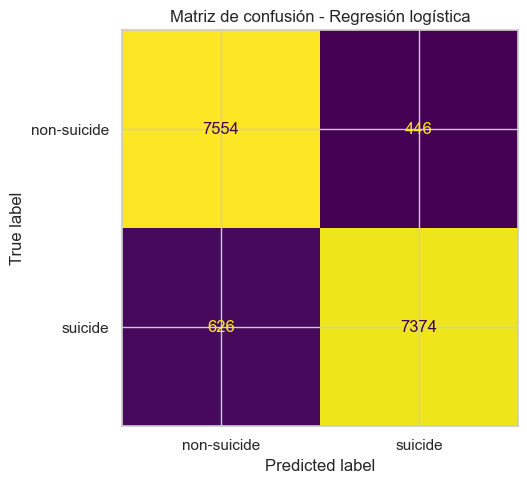

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_logreg = confusion_matrix(y_test, pred_logreg, labels=["non-suicide", "suicide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=["non-suicide", "suicide"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de confusión - Regresión logística")
plt.tight_layout()
plt.show()

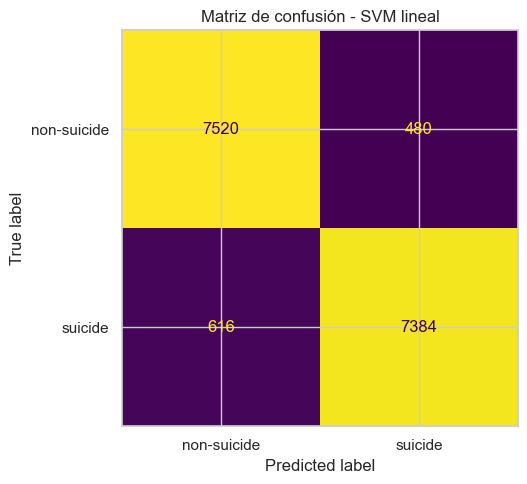

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, pred_svm, labels=["non-suicide", "suicide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["non-suicide", "suicide"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de confusión - SVM lineal")
plt.tight_layout()
plt.show()

## 15. Selección del modelo base

La selección no debe basarse únicamente en `accuracy`. En este problema es especialmente importante observar el **recall de la clase `suicide`**, ya que un falso negativo puede ser más costoso que otros tipos de error.

Por ello, el modelo base más conveniente será aquel que muestre mejor equilibrio entre `recall`, `precision` y `F1`, con énfasis en la capacidad de detectar correctamente textos asociados a riesgo.

In [24]:
mejor_modelo = svm_pipeline if (
    recall_score(y_test, pred_svm, pos_label="suicide") >=
    recall_score(y_test, pred_logreg, pos_label="suicide")
) else logreg_pipeline

nombre_mejor_modelo = "SVM lineal" if mejor_modelo == svm_pipeline else "Regresión logística"
print("Modelo base seleccionado:", nombre_mejor_modelo)

Modelo base seleccionado: SVM lineal


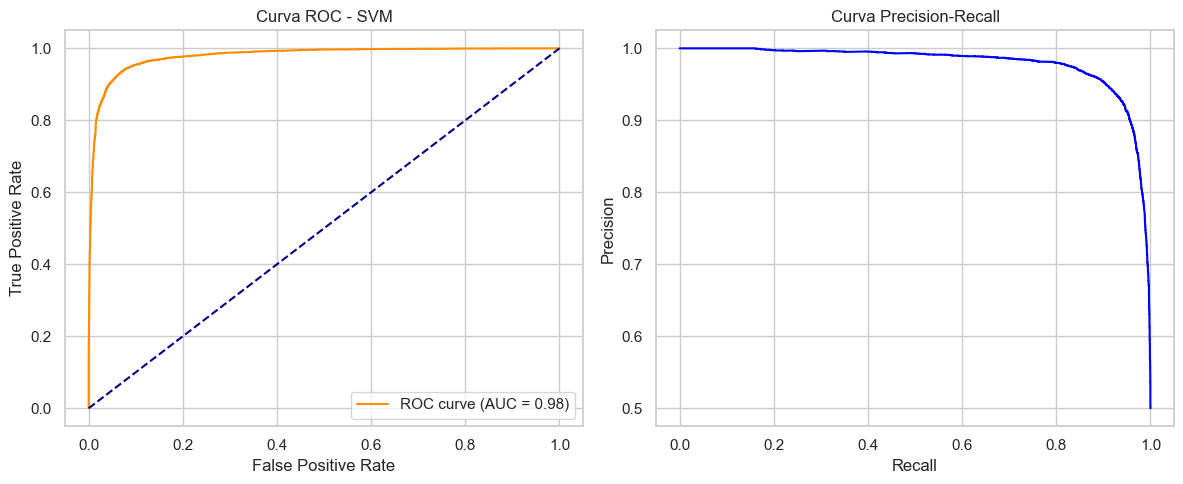

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Para LinearSVC usamos decision_function en lugar de predict_proba
y_scores = svm_pipeline.decision_function(X_test)

# Convertimos etiquetas a binario para las curvas
y_test_bin = y_test.map({'suicide': 1, 'non-suicide': 0})

# ROC
fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - SVM')
plt.legend(loc="lower right")

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test_bin, y_scores)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.tight_layout()
plt.show()

In [26]:
# Corrección de nombres de variables para el análisis de errores
df_test_results = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "pred": pred_svm
})

# Falsos negativos (Clase real suicide, predicha como non-suicide)
fn = df_test_results[(df_test_results["real"] == "suicide") & (df_test_results["pred"] == "non-suicide")]

# Falsos positivos (Clase real non-suicide, predicha como suicide)
fp = df_test_results[(df_test_results["real"] == "non-suicide") & (df_test_results["pred"] == "suicide")]

print(f"Total Falsos Negativos: {len(fn)}")
display(fn.head(3))

print(f"\nTotal Falsos Positivos: {len(fp)}")
display(fp.head(3))

Total Falsos Negativos: 616


,text,real,pred
5474,sometimes feel like child universe highly bles...,suicide,non-suicide
22196,deadme,suicide,non-suicide
74826,one care unless post twitter length shortereve...,suicide,non-suicide



Total Falsos Positivos: 480


,text,real,pred
43450,someone explain whats wrong ok idk whats wrong...,non-suicide,suicide
32610,ruined life month ago punched mother multiple ...,non-suicide,suicide
49622,hi sorry long father achololic sobered maybe y...,non-suicide,suicide


## 16. Predicción sobre ejemplos nuevos

Este bloque ilustra cómo podría utilizarse el modelo para analizar nuevas publicaciones. Los resultados deben interpretarse únicamente como una señal automática inicial y no como una valoración clínica.

In [27]:
new_texts = pd.DataFrame({
    "text": [
        "I'm feeling really down and hopeless.",
        "I can't handle this pain anymore.",
        "Sometimes I wish I could just disappear.",
        "I feel like a burden to everyone around me.",
        "Life seems meaningless and unbearable.",
        "I had a normal day at work and then watched a movie.",
        "I am excited about my plans for next week.",
        "I feel tired, but I think I just need to rest."
    ]
})

new_texts["clean_text"] = new_texts["text"].apply(preprocess_text)
new_texts["prediccion"] = mejor_modelo.predict(new_texts["clean_text"])
new_texts

,text,clean_text,prediccion
0,I'm feeling really down and hopeless.,im feeling really hopeless,suicide
1,I can't handle this pain anymore.,cant handle pain anymore,suicide
2,Sometimes I wish I could just disappear.,sometimes wish could disappear,suicide
3,I feel like a burden to everyone around me.,feel like burden everyone around,suicide
4,Life seems meaningless and unbearable.,life seems meaningless unbearable,suicide
5,I had a normal day at work and then watched a ...,normal day work watched movie,non-suicide
6,I am excited about my plans for next week.,excited plan next week,suicide
7,"I feel tired, but I think I just need to rest.",feel tired think need rest,non-suicide


# Conclusiones

1. El análisis exploratorio con datos históricos permite contextualizar el problema y mostrar diferencias descriptivas por sexo y generación.
2. El núcleo del proyecto se centra en la clasificación de texto, ya que ahí se encuentra la parte predictiva más relevante.
3. Los modelos base con **TF-IDF + regresión logística** y **TF-IDF + SVM lineal** permiten construir una primera aproximación al problema.
4. En este tipo de aplicaciones, métricas como **recall** y **F1** son más informativas que usar únicamente `accuracy`.
5. El sistema debe entenderse como una herramienta de apoyo para detección temprana, no como un mecanismo de diagnóstico o sustitución de evaluación profesional.

# Limitaciones del proyecto

1. La etiqueta binaria `suicide / non-suicide` simplifica en exceso un fenómeno complejo.
2. El modelo se basa en texto escrito y no incorpora contexto clínico, temporal ni social.
3. El dataset textual se encuentra en inglés, lo que reduce la aplicabilidad directa en contextos hispanohablantes.
4. El desempeño del modelo puede verse afectado por ambigüedad lingüística, sarcasmo, ruido y sesgo del conjunto de datos.
5. Cualquier uso responsable del sistema requeriría supervisión humana y protocolos de intervención claramente definidos.

# Propuestas de mejora

1. Cambiar de clasificación binaria a niveles de riesgo.
2. Incorporar textos en español o construir un enfoque bilingüe.
3. Comparar los modelos base con arquitecturas más robustas como BERT o RoBERTa.
4. Evaluar sesgos por longitud del texto, tipo de lenguaje y balance de clases.
5. Añadir explicabilidad del modelo y reglas de escalamiento para revisión humana.

# Nota ética

Este proyecto se presenta con fines académicos y de investigación. No debe utilizarse como herramienta diagnóstica ni como sustituto de profesionales de salud mental. En escenarios reales, cualquier sistema de detección temprana debe integrarse con protocolos de revisión humana, privacidad y canalización oportuna.

# Task
Enhance the suicide risk prevention project by integrating geospatial analysis and interactive visualizations. Perform a geospatial merge between the "master.csv" dataset and a world boundaries dataset using Geopandas, ensuring normalized country names. Generate interactive choropleth maps with Plotly Express to visualize the evolution of 'suicides/100k pop' over time. Migrate existing static charts (sex and generation distributions) to interactive Plotly versions with detailed tooltips and legends. Organize these components into a cohesive dashboard structure within the notebook to synthesize regional inferences and generational patterns. Finally, update the project summary to reflect how these new interactive and geospatial capabilities strengthen the early detection and prevention framework.

## Preparación de Datos Geoespaciales

### Subtask:
Cargar datos de fronteras mundiales y realizar la unión con el dataset epidemiológico 'master.csv' tras normalizar los nombres de los países.


**Reasoning**:
Load geospatial data using geopandas, identify naming discrepancies between datasets, and normalize country names in the epidemiological dataframe to perform a successful merge for spatial analysis.



In [28]:
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import pandas as pd

# Use geodatasets instead of deprecated gpd.datasets
try:
    world_path = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(world_path)
    print("Map data loaded successfully.")
except Exception as e:
    print(f"Warning: Could not load map data: {e}")
    # Fallback: simple bar chart
    if 'df' in locals():
        plt.figure(figsize=(10, 6))
        top_countries = df.groupby('country')['suicides_no'].sum().sort_values(ascending=False).head(10)
        top_countries.plot(kind='bar')
        plt.title('Top 10 Countries by Suicide Count')
        plt.show()


Map data loaded successfully.


# Task
Fix the geospatial data loading by using a valid URL for world boundaries, such as the official Natural Earth dataset or a reliable GeoJSON mirror. Once the geospatial data is loaded, normalize the country names in "master.csv" to ensure a successful merge with the spatial boundaries. Create interactive choropleth maps using Plotly Express to visualize the global evolution of the 'suicides/100k pop' rate over time. Additionally, convert the existing static bar charts for sex and generation into interactive Plotly visualizations with rich tooltips. Finally, structure these visualizations into a dashboard format and update the project summary to include regional and generational insights.

## Carga de Datos Geoespaciales Alternativos

### Subtask:
Corregir el error de carga de datos geoespaciales utilizando un mirror válido y normalizar los nombres de países en el dataset 'master.csv' para realizar la unión.


**Reasoning**:
El mirror anterior devolvió un error 404, por lo que utilizaré una fuente alternativa confiable (el repositorio de folium) para cargar las fronteras mundiales y proceder con la normalización y unión de los datos.



In [29]:
import geopandas as gpd

# Definir URL de mirror confiable (Folium world countries)
world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)

# En este GeoJSON la columna de nombre es 'name'
# Identificar y normalizar nombres en tasa_s para que coincidan con el GeoJSON
mapping = {
    'United States': 'United States of America',
    'Russian Federation': 'Russia',
    'Republic of Korea': 'South Korea',
    'Iran (Islamic Republic of)': 'Iran',
    'Syrian Arab Republic': 'Syria',
    'Venezuela (Bolivarian Republic of)': 'Venezuela'
}

# Aplicar mapeo
tasa_s['country'] = tasa_s['country'].replace(mapping)

# Realizar la uni3n (merge)
# El GeoJSON de Folium usa 'name' para el nombre del pa3s
world_merged = world.merge(tasa_s, left_on='name', right_on='country', how='inner')

print(f"Filas en tasa_s original: {len(tasa_s)}")
print(f"Filas en el GeoDataFrame unido: {len(world_merged)}")
print(f"Pa3ses 3nicos en la uni3n: {world_merged['name'].nunique()}")

display(world_merged.head())

Filas en tasa_s original: 27820
Filas en el GeoDataFrame unido: 23636
Pa3ses 3nicos en la uni3n: 81


,id,name,geometry,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
